# Exploración de Patologías por Dataset
Datasets analizados: **ChestXray8**, **CheXpert**, **VinBigData**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 1. ChestXray8

In [2]:
cx8 = pd.read_csv(r"ChestXray8/Data_Entry_2017.csv")

cx8_labels = cx8["Finding Labels"].str.split("|").explode()
cx8_counts = cx8_labels.value_counts()

print(f"Total imágenes : {len(cx8):,}")
print(f"Patologías únicas: {cx8_counts.index.nunique()}\n")
print(cx8_counts.to_string())

Total imágenes : 112,120
Patologías únicas: 15

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227


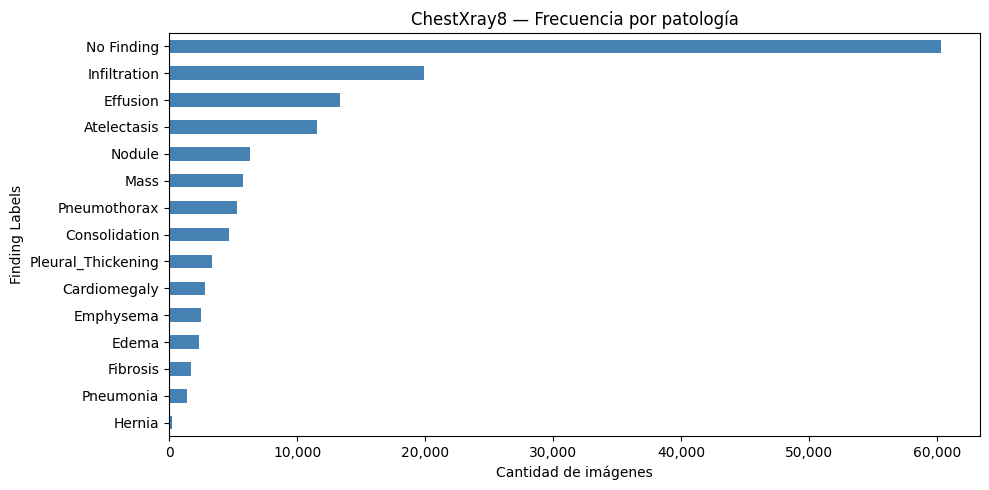

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
cx8_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("ChestXray8 — Frecuencia por patología")
ax.set_xlabel("Cantidad de imágenes")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 1b. ChestXray8 — BBox (patologías con localización)

In [4]:
cx8_bbox = pd.read_csv(r"ChestXray8/BBox_List_2017.csv")
bbox_counts = cx8_bbox["Finding Label"].value_counts()

print(f"Total bounding boxes: {len(cx8_bbox):,}")
print(f"Patologías con bbox : {bbox_counts.index.nunique()}\n")
print(bbox_counts.to_string())

Total bounding boxes: 984
Patologías con bbox : 8

Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79


## 2. CheXpert

In [5]:
CHEXPERT_LABELS = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly",
    "Lung Opacity", "Lung Lesion", "Edema", "Consolidation",
    "Pneumonia", "Atelectasis", "Pneumothorax",
    "Pleural Effusion", "Pleural Other", "Fracture", "Support Devices"
]

chex_train = pd.read_csv(r"chexpert/train.csv")
chex_valid = pd.read_csv(r"chexpert/valid.csv")
chex = pd.concat([chex_train, chex_valid], ignore_index=True)

chex_pos = (chex[CHEXPERT_LABELS] == 1).sum().sort_values(ascending=False)

print(f"Total estudios (train+valid): {len(chex):,}")
print(f"Patologías/etiquetas        : {len(CHEXPERT_LABELS)}\n")
print("Positivos por etiqueta:")
print(chex_pos.to_string())

Total estudios (train+valid): 223,648
Patologías/etiquetas        : 14

Positivos por etiqueta:
Support Devices               116108
Lung Opacity                  105707
Pleural Effusion               86254
Edema                          52291
Atelectasis                    33456
Cardiomegaly                   27068
No Finding                     22419
Pneumothorax                   19456
Consolidation                  14816
Enlarged Cardiomediastinum     10907
Lung Lesion                     9187
Fracture                        9040
Pneumonia                       6047
Pleural Other                   3524


In [6]:
value_dist = {}
for col in CHEXPERT_LABELS:
    vc = chex[col].value_counts(dropna=False)
    value_dist[col] = {
        "Positivo (1)": int(vc.get(1.0, 0)),
        "Negativo (0)": int(vc.get(0.0, 0)),
        "Incierto (-1)": int(vc.get(-1.0, 0)),
        "No mencionado": int(vc.get(float("nan"), 0) or chex[col].isna().sum()),
    }

dist_df = pd.DataFrame(value_dist).T
print(dist_df.to_string())

                            Positivo (1)  Negativo (0)  Incierto (-1)  No mencionado
No Finding                         22419           196              0         201033
Enlarged Cardiomediastinum         10907         21763          12403         178575
Cardiomegaly                       27068         11282           8087         177211
Lung Opacity                      105707          6707           5598         105636
Lung Lesion                         9187          1503           1488         211470
Edema                              52291         20915          12984         137458
Consolidation                      14816         28298          27742         152792
Pneumonia                           6047          3025          18770         195806
Atelectasis                        33456          1482          33739         154971
Pneumothorax                       19456         56567           3145         144480
Pleural Effusion                   86254         35563          1

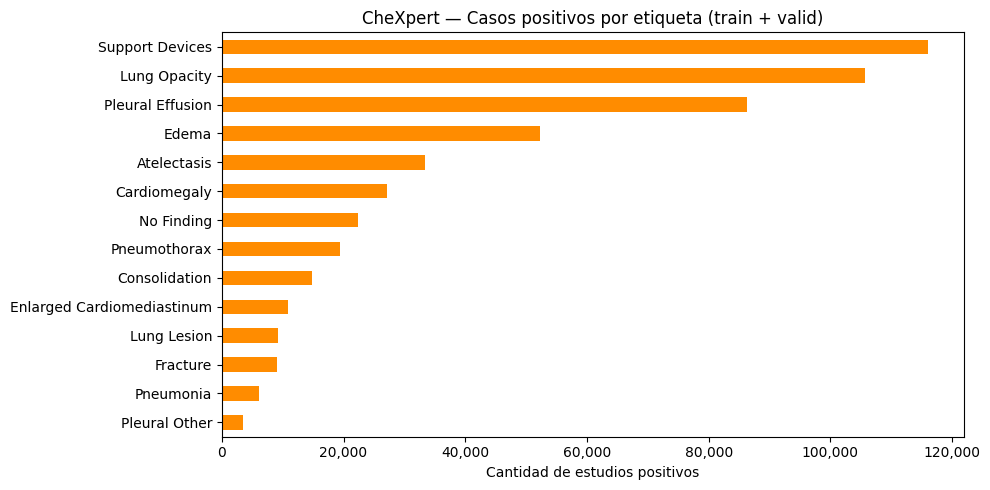

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
chex_pos.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("CheXpert — Casos positivos por etiqueta (train + valid)")
ax.set_xlabel("Cantidad de estudios positivos")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3. VinBigData

In [8]:
vin = pd.read_csv(r"VinBigData/train.csv", index_col=0)

class_table = (
    vin[["class_name", "class_id"]]
    .drop_duplicates()
    .sort_values("class_id")
    .reset_index(drop=True)
)

print(f"Total anotaciones: {len(vin):,}")
print(f"Imágenes únicas  : {vin['image_id'].nunique():,}")
print(f"Clases (patologías): {vin['class_name'].nunique()}\n")
print(class_table.to_string(index=False))

Total anotaciones: 67,914
Imágenes únicas  : 15,000
Clases (patologías): 15

        class_name  class_id
Aortic enlargement         0
       Atelectasis         1
     Calcification         2
      Cardiomegaly         3
     Consolidation         4
               ILD         5
      Infiltration         6
      Lung Opacity         7
       Nodule/Mass         8
      Other lesion         9
  Pleural effusion        10
Pleural thickening        11
      Pneumothorax        12
Pulmonary fibrosis        13
        No finding        14


In [9]:
vin_img_counts = (
    vin.groupby("class_name")["image_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Imágenes únicas por clase:")
print(vin_img_counts.to_string())

Imágenes únicas por clase:
class_name
No finding            10606
Aortic enlargement     3067
Cardiomegaly           2300
Pleural thickening     1981
Pulmonary fibrosis     1617
Lung Opacity           1322
Other lesion           1134
Pleural effusion       1032
Nodule/Mass             826
Infiltration            613
Calcification           452
ILD                     386
Consolidation           353
Atelectasis             186
Pneumothorax             96


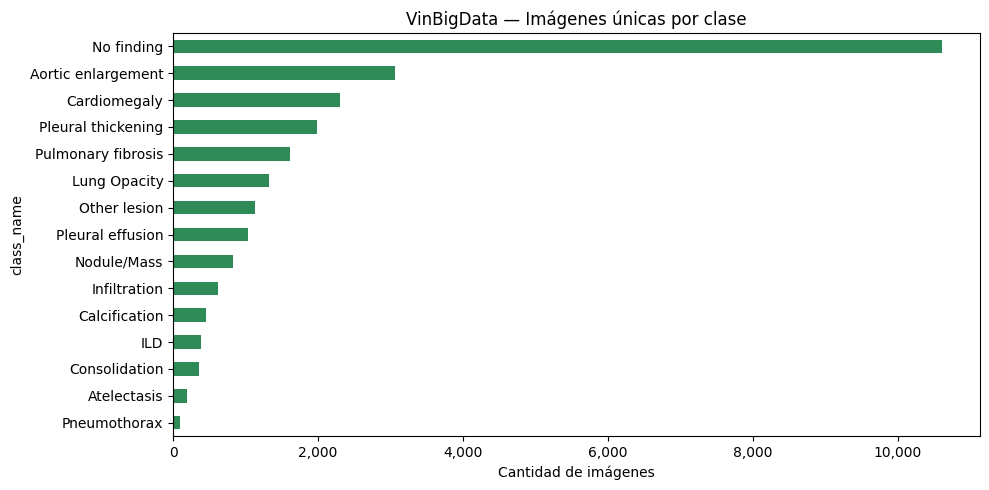

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
vin_img_counts.sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("VinBigData — Imágenes únicas por clase")
ax.set_xlabel("Cantidad de imágenes")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 4. Comparación entre datasets

In [11]:
cx8_set  = set(cx8_counts.index)
chex_set = set(CHEXPERT_LABELS)
vin_set  = set(vin["class_name"].unique())

all_labels = sorted(cx8_set | chex_set | vin_set)

comparison = pd.DataFrame(
    {
        "ChestXray8": ["✓" if l in cx8_set  else "" for l in all_labels],
        "CheXpert"  : ["✓" if l in chex_set else "" for l in all_labels],
        "VinBigData": ["✓" if l in vin_set  else "" for l in all_labels],
    },
    index=all_labels,
)

print(comparison.to_string())

                           ChestXray8 CheXpert VinBigData
Aortic enlargement                                      ✓
Atelectasis                         ✓        ✓          ✓
Calcification                                           ✓
Cardiomegaly                        ✓        ✓          ✓
Consolidation                       ✓        ✓          ✓
Edema                               ✓        ✓           
Effusion                            ✓                    
Emphysema                           ✓                    
Enlarged Cardiomediastinum                   ✓           
Fibrosis                            ✓                    
Fracture                                     ✓           
Hernia                              ✓                    
ILD                                                     ✓
Infiltration                        ✓                   ✓
Lung Lesion                                  ✓           
Lung Opacity                                 ✓          ✓
Mass          

## 5. Dataset Unificado de Clasificación
Diccionario de mapeo canónico + loaders por dataset + unificación en un único DataFrame multi-label.

In [12]:
CANONICAL_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Pleural_Effusion", "Pneumonia", "Pneumothorax",
    "Infiltration", "Nodule_Mass", "Pleural_Thickening", "No_Finding",
]

# label_original -> label_canonico  (None = descartar)
CX8_MAP = {
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Edema":              "Edema",
    "Effusion":           "Pleural_Effusion",
    "Pneumonia":          "Pneumonia",
    "Pneumothorax":       "Pneumothorax",
    "Infiltration":       "Infiltration",
    "Nodule":             "Nodule_Mass",
    "Mass":               "Nodule_Mass",
    "Pleural_Thickening": "Pleural_Thickening",
    "No Finding":         "No_Finding",
    "Emphysema": None, "Fibrosis": None, "Hernia": None,
}

CHEXPERT_MAP = {
    "Atelectasis":                "Atelectasis",
    "Cardiomegaly":               "Cardiomegaly",
    "Consolidation":              "Consolidation",
    "Edema":                      "Edema",
    "Pleural Effusion":           "Pleural_Effusion",
    "Pneumonia":                  "Pneumonia",
    "Pneumothorax":               "Pneumothorax",
    "No Finding":                 "No_Finding",
    "Enlarged Cardiomediastinum": None,
    "Lung Opacity":               None,
    "Lung Lesion":                None,
    "Pleural Other":              None,
    "Fracture":                   None,
    "Support Devices":            None,
}

VIN_MAP = {
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Pleural effusion":   "Pleural_Effusion",
    "Pneumothorax":       "Pneumothorax",
    "Infiltration":       "Infiltration",
    "Nodule/Mass":        "Nodule_Mass",
    "Pleural thickening": "Pleural_Thickening",
    "No finding":         "No_Finding",
    "Aortic enlargement": None,
    "Calcification":      None,
    "ILD":                None,
    "Lung Opacity":       None,
    "Other lesion":       None,
    "Pulmonary fibrosis": None,
}

print("Labels canonicos definidos:", len(CANONICAL_LABELS))
print(CANONICAL_LABELS)

Labels canonicos definidos: 11
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


In [13]:
def load_chestxray8(csv_path, label_map, canonical_labels):
    df = pd.read_csv(csv_path)
    rows = []
    for _, row in df.iterrows():
        labels = row["Finding Labels"].split("|")
        canonical = {c: 0.0 for c in canonical_labels}
        for lbl in labels:
            mapped = label_map.get(lbl.strip())
            if mapped is not None:
                canonical[mapped] = 1.0
        rows.append({
            "image_id":   row["Image Index"],
            "source":     "chestxray8",
            "image_path": f"ChestXray8/images/{row['Image Index']}",
            **canonical,
        })
    return pd.DataFrame(rows)


df_cx8 = load_chestxray8(r"ChestXray8/Data_Entry_2017.csv", CX8_MAP, CANONICAL_LABELS)
print(f"ChestXray8 - filas: {len(df_cx8):,}")
df_cx8.head(3)

ChestXray8 - filas: 112,120


,image_id,source,image_path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural_Effusion,Pneumonia,Pneumothorax,Infiltration,Nodule_Mass,Pleural_Thickening,No_Finding
0,00000001_000.png,chestxray8,ChestXray8/images/00000001_000.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,00000001_001.png,chestxray8,ChestXray8/images/00000001_001.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,00000001_002.png,chestxray8,ChestXray8/images/00000001_002.png,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
def _chex_path_to_flat(orig_path):
    parts = orig_path.split("/")
    patient, study, fname = parts[2], parts[3], parts[4]
    return "/".join(parts[:2]) + f"/{patient}_{study}_{fname}"


def load_chexpert(train_path, valid_path, label_map, canonical_labels):
    raw = pd.concat([pd.read_csv(train_path), pd.read_csv(valid_path)], ignore_index=True)

    # Conservar solo vistas frontales (PA/AP); descartar laterales
    raw = raw[raw["Frontal/Lateral"] == "Frontal"].drop(columns=["Frontal/Lateral", "AP/PA"])

    rename = {orig: canon for orig, canon in label_map.items() if canon is not None}
    drop   = [orig for orig, canon in label_map.items() if canon is None]
    raw = raw.rename(columns=rename).drop(columns=drop, errors="ignore")
    for col in canonical_labels:
        if col in raw.columns:
            raw[col] = raw[col].replace(-1.0, float("nan"))
        else:
            raw[col] = float("nan")
    raw["image_id"]   = raw["Path"].apply(lambda p: _chex_path_to_flat(p).split("/")[-1])
    raw["source"]     = "chexpert"
    raw["image_path"] = raw["Path"].apply(_chex_path_to_flat)
    return raw[["image_id", "source", "image_path"] + canonical_labels]


df_chex = load_chexpert(r"chexpert/train.csv", r"chexpert/valid.csv", CHEXPERT_MAP, CANONICAL_LABELS)
print(f"CheXpert - filas: {len(df_chex):,}  (solo frontales)")
df_chex.head(3)


CheXpert - filas: 191,229  (solo frontales)


,image_id,source,image_path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural_Effusion,Pneumonia,Pneumothorax,Infiltration,Nodule_Mass,Pleural_Thickening,No_Finding
0,patient00001_study1_view1_frontal.jpg,chexpert,CheXpert-v1.0-small/train/patient00001_study1_...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,patient00002_study2_view1_frontal.jpg,chexpert,CheXpert-v1.0-small/train/patient00002_study2_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,patient00002_study1_view1_frontal.jpg,chexpert,CheXpert-v1.0-small/train/patient00002_study1_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
def load_vinbigdata(csv_path, label_map, canonical_labels):
    raw = pd.read_csv(csv_path, index_col=0)
    raw["canonical"] = raw["class_name"].map(label_map)
    raw = raw[raw["canonical"].notna()]

    total_rads = raw.groupby("image_id")["rad_id"].nunique().rename("total_rads")

    votes = (
        raw[raw["canonical"] != "No_Finding"]
        .groupby(["image_id", "canonical"])["rad_id"]
        .nunique()
        .reset_index(name="pos_votes")
    )
    votes = votes.join(total_rads, on="image_id")
    votes["label"] = (votes["pos_votes"] / votes["total_rads"] >= 0.5).astype(float)

    pivot = votes.pivot_table(index="image_id", columns="canonical", values="label", aggfunc="max")
    pivot = pivot.reindex(columns=canonical_labels)

    no_finding_imgs = set(
        raw.groupby("image_id")
        .filter(lambda g: (g["canonical"] == "No_Finding").all())["image_id"]
    )
    pivot["No_Finding"] = pivot.index.map(lambda i: 1.0 if i in no_finding_imgs else 0.0)

    mapped_in_vin = {v for v in label_map.values() if v is not None}
    for col in canonical_labels:
        if col in mapped_in_vin:
            pivot[col] = pivot[col].fillna(0.0)
        else:
            pivot[col] = float("nan")

    pivot = pivot.reset_index()
    pivot["source"]     = "vinbigdata"
    pivot["image_path"] = pivot["image_id"].apply(lambda i: f"VinBigData/train/{i}.dicom")
    return pivot[["image_id", "source", "image_path"] + canonical_labels]


df_vin = load_vinbigdata(r"VinBigData/train.csv", VIN_MAP, CANONICAL_LABELS)
print(f"VinBigData - filas: {len(df_vin):,}")
df_vin.head(3)

VinBigData - filas: 4,002


canonical,image_id,source,image_path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural_Effusion,Pneumonia,Pneumothorax,Infiltration,Nodule_Mass,Pleural_Thickening,No_Finding
0,0005e8e3701dfb1dd93d53e2ff537b6e,vinbigdata,VinBigData/train/0005e8e3701dfb1dd93d53e2ff537...,0.0,0.0,1.0,NaN,0.0,NaN,0.0,1.0,1.0,0.0,0.0
1,0007d316f756b3fa0baea2ff514ce945,vinbigdata,VinBigData/train/0007d316f756b3fa0baea2ff514ce...,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,0.0
2,000d68e42b71d3eac10ccc077aba07c1,vinbigdata,VinBigData/train/000d68e42b71d3eac10ccc077aba0...,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,0.0


In [16]:
unified = pd.concat([df_cx8, df_chex, df_vin], ignore_index=True)

print(f"Dataset unificado - total filas: {len(unified):,}\n")
print("Filas por dataset:")
print(unified["source"].value_counts().to_string())

coverage = unified[CANONICAL_LABELS].notna().mean().rename("cobertura").to_frame()
coverage["NaN %"]     = ((1 - coverage["cobertura"]) * 100).round(1)
coverage["positivos"] = (unified[CANONICAL_LABELS] == 1.0).sum().values
coverage["cobertura"] = coverage["cobertura"].round(3)
print("\nCobertura y positivos por label canonico:")
print(coverage.to_string())

Dataset unificado - total filas: 307,351

Filas por dataset:
source
chexpert      191229
chestxray8    112120
vinbigdata      4002

Cobertura y positivos por label canonico:
                    cobertura  NaN %  positivos
Atelectasis             0.479   52.1      41454
Cardiomegaly            0.480   52.0      28361
Consolidation           0.485   51.5      17856
Edema                   0.579   42.1      52020
Pleural_Effusion        0.711   28.9      91083
Pneumonia               0.387   61.3       6114
Pneumothorax            0.592   40.8      23069
Infiltration            0.378   62.2      20315
Nodule_Mass             0.378   62.2      11809
Pleural_Thickening      0.378   62.2       4766
No_Finding              0.434   56.6      77361


In [17]:
import os

OUTPUT_PATH = r"unified_dataset.csv"

unified.to_csv(OUTPUT_PATH, index=False)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 ** 2)
print(f"Guardado en: {os.path.abspath(OUTPUT_PATH)}")
print(f"Filas: {len(unified):,}  |  Columnas: {len(unified.columns)}  |  Tamaño: {size_mb:.1f} MB")
print(f"\nColumnas: {list(unified.columns)}")

Guardado en: e:\dataset\unified_dataset.csv
Filas: 307,351  |  Columnas: 14  |  Tamaño: 35.6 MB

Columnas: ['image_id', 'source', 'image_path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


## 6. Split Train / Test
- **ChestXray8**: split oficial (`train_val_list.txt` / `test_list.txt`)
- **CheXpert**: split oficial (`train.csv` / `valid.csv`)
- **VinBigData**: split aleatorio 80/20 por `image_id` (seed=42)

In [18]:
# --- ChestXray8: splits oficiales desde TXT ---
with open(r"ChestXray8/train_val_list.txt") as f:
    cx8_train_ids = set(f.read().splitlines())
with open(r"ChestXray8/test_list.txt") as f:
    cx8_test_ids = set(f.read().splitlines())

df_cx8["split"] = df_cx8["image_id"].map(
    lambda x: "train" if x in cx8_train_ids else ("test" if x in cx8_test_ids else "unknown")
)

# --- CheXpert: reconstruir split leyendo solo columna Path ---
chex_train_ids = set(
    pd.read_csv(r"chexpert/train.csv", usecols=["Path"])["Path"]
    .apply(lambda p: _chex_path_to_flat(p).split("/")[-1])
)
chex_valid_ids = set(
    pd.read_csv(r"chexpert/valid.csv", usecols=["Path"])["Path"]
    .apply(lambda p: _chex_path_to_flat(p).split("/")[-1])
)

df_chex["split"] = df_chex["image_id"].map(
    lambda x: "train" if x in chex_train_ids else ("test" if x in chex_valid_ids else "unknown")
)

# --- VinBigData: split aleatorio 80/20 a nivel image_id ---
vin_ids = pd.Series(df_vin["image_id"].unique())
vin_test_ids  = set(vin_ids.sample(frac=0.2, random_state=42))
vin_train_ids = set(vin_ids) - vin_test_ids

df_vin["split"] = df_vin["image_id"].map(
    lambda x: "train" if x in vin_train_ids else "test"
)

print("Split ChestXray8:", df_cx8["split"].value_counts().to_dict())
print("Split CheXpert:  ", df_chex["split"].value_counts().to_dict())
print("Split VinBigData:", df_vin["split"].value_counts().to_dict())


Split ChestXray8: {'train': 86524, 'test': 25596}
Split CheXpert:   {'train': 191027, 'test': 202}
Split VinBigData: {'train': 3202, 'test': 800}


In [19]:
import os

unified_split = pd.concat([df_cx8, df_chex, df_vin], ignore_index=True)

train_df = unified_split[unified_split["split"] == "train"].drop(columns=["split"]).reset_index(drop=True)
test_df  = unified_split[unified_split["split"] == "test"].drop(columns=["split"]).reset_index(drop=True)

train_df.to_csv(r"unified_train.csv", index=False)
test_df.to_csv(r"unified_test.csv",  index=False)

train_mb = os.path.getsize(r"unified_train.csv") / (1024 ** 2)
test_mb  = os.path.getsize(r"unified_test.csv")  / (1024 ** 2)

print(f"unified_train.csv — filas: {len(train_df):,}  ({train_mb:.1f} MB)")
print(f"unified_test.csv  — filas: {len(test_df):,}  ({test_mb:.1f} MB)")
print(f"\nTrain por fuente:")
print(train_df["source"].value_counts().to_string())
print(f"\nTest por fuente:")
print(test_df["source"].value_counts().to_string())
assert len(train_df) + len(test_df) == len(unified_split[unified_split["split"].isin(["train","test"])]), "Hay filas sin asignar"

unified_train.csv — filas: 280,753  (32.8 MB)
unified_test.csv  — filas: 26,598  (2.8 MB)

Train por fuente:
source
chexpert      191027
chestxray8     86524
vinbigdata      3202

Test por fuente:
source
chestxray8    25596
vinbigdata      800
chexpert        202


## 7. Corrección de Paths y Split de Validación
Los paths generados en las secciones anteriores tienen inconsistencias:
- **ChestXray8**: las imágenes están en `images_001/images/` … `images_012/images/`, no en `images/`
- **VinBigData**: los archivos son `.jpg`, no `.dicom`
- **CheXpert**: el prefijo original es `CheXpert-v1.0-small/` pero el directorio real es `chexpert/`

Esta sección corrige los paths y genera los splits finales en `data/`.

In [20]:
import os
import glob
import pandas as pd

# --- Construir lookup filename -> path real para ChestXray8 ---
print("Construyendo lookup ChestXray8 (puede tardar unos segundos)...")
cx8_lookup = {}
for part_dir in sorted(glob.glob(r"ChestXray8/images_*/images/")):
    for fname in os.listdir(part_dir):
        cx8_lookup[fname] = part_dir.replace("\\", "/") + fname

print(f"  → {len(cx8_lookup):,} imágenes indexadas")

# --- Corregir y guardar los 3 CSVs ---
for csv_path in ["unified_train.csv", "unified_test.csv", "unified_dataset.csv"]:
    df = pd.read_csv(csv_path)
    original_len = len(df)

    # ChestXray8: usar lookup
    mask_cx8 = df["source"] == "chestxray8"
    df.loc[mask_cx8, "image_path"] = df.loc[mask_cx8, "image_id"].map(cx8_lookup)

    # VinBigData: .dicom -> .jpg
    mask_vin = df["source"] == "vinbigdata"
    df.loc[mask_vin, "image_path"] = df.loc[mask_vin, "image_path"].str.replace(".dicom", ".jpg", regex=False)

    # CheXpert: prefijo correcto
    mask_chex = df["source"] == "chexpert"
    df.loc[mask_chex, "image_path"] = df.loc[mask_chex, "image_path"].str.replace(
        "CheXpert-v1.0-small/", "chexpert/", regex=False
    )

    df.to_csv(csv_path, index=False)
    assert len(df) == original_len
    print(f"  ✓ {csv_path} corregido ({original_len:,} filas)")

print("\nPaths corregidos correctamente.")

Construyendo lookup ChestXray8 (puede tardar unos segundos)...
  → 112,120 imágenes indexadas
  ✓ unified_train.csv corregido (280,753 filas)
  ✓ unified_test.csv corregido (26,598 filas)
  ✓ unified_dataset.csv corregido (307,351 filas)

Paths corregidos correctamente.


In [21]:
import random

# Verificar que los paths existen en disco
random.seed(42)

train_df = pd.read_csv("unified_train.csv")
test_df  = pd.read_csv("unified_test.csv")

all_ok = True
for source in ["chestxray8", "chexpert", "vinbigdata"]:
    sample = train_df[train_df["source"] == source]["image_path"].dropna().sample(5, random_state=42).tolist()
    results = [(p, os.path.exists(p)) for p in sample]
    ok = all(r[1] for r in results)
    all_ok = all_ok and ok
    status = "✓" if ok else "✗"
    print(f"{status} {source}:")
    for path, exists in results:
        print(f"   {'OK' if exists else 'MISSING'}: {path}")

print(f"\nVerificación: {'TODOS OK' if all_ok else 'HAY PATHS FALTANTES'}")

✓ chestxray8:
   OK: ChestXray8/images_012/images/00028324_001.png
   OK: ChestXray8/images_004/images/00006949_004.png
   OK: ChestXray8/images_002/images/00003923_000.png
   OK: ChestXray8/images_008/images/00017365_002.png
   OK: ChestXray8/images_009/images/00018947_001.png
✓ chexpert:
   OK: chexpert/train/patient18339_study18_view1_frontal.jpg
   OK: chexpert/train/patient45651_study4_view1_frontal.jpg
   OK: chexpert/train/patient53552_study1_view1_frontal.jpg
   OK: chexpert/train/patient07442_study1_view1_frontal.jpg
   OK: chexpert/train/patient61350_study1_view1_frontal.jpg
✓ vinbigdata:
   OK: VinBigData/train/c6221295778a330b5b3fa85e719ee9e8.jpg
   OK: VinBigData/train/1c4d37f9cbacdce0f114ed4c3fd94dd5.jpg
   OK: VinBigData/train/498ac0c4815a890629cf509446a47238.jpg
   OK: VinBigData/train/a30e54c94c56cf1448eb8f3921a40e15.jpg
   OK: VinBigData/train/1e717af900c3f539f967ad27b1ce905f.jpg

Verificación: TODOS OK


In [22]:
from sklearn.model_selection import train_test_split

train_full = pd.read_csv("unified_train.csv")
test_df    = pd.read_csv("unified_test.csv")

# CheXpert: image_id = "patient00001_study1_view1_frontal.jpg" -> partes[0] = "patient00001"
def get_split_key(row):
    if row["source"] == "chexpert":
        return row["image_id"].split("_")[0]
    return row["image_id"]

train_full["_split_key"] = train_full.apply(get_split_key, axis=1)

unique_keys = train_full["_split_key"].unique()
train_keys, val_keys = train_test_split(unique_keys, test_size=0.15, random_state=42)

df_train_final = train_full[train_full["_split_key"].isin(train_keys)].drop(columns=["_split_key"]).reset_index(drop=True)
df_val_final   = train_full[train_full["_split_key"].isin(val_keys)].drop(columns=["_split_key"]).reset_index(drop=True)

os.makedirs("data", exist_ok=True)
df_train_final.to_csv("data/train.csv", index=False)
df_val_final.to_csv("data/val.csv",   index=False)
test_df.to_csv("data/test.csv",        index=False)

print(f"data/train.csv --- {len(df_train_final):,} filas")
print(f"data/val.csv   --- {len(df_val_final):,} filas")
print(f"data/test.csv  --- {len(test_df):,} filas")
print(f"\nDistribucion por fuente en train:")
print(df_train_final["source"].value_counts().to_string())
print(f"\nDistribucion por fuente en val:")
print(df_val_final["source"].value_counts().to_string())


data/train.csv --- 238,504 filas
data/val.csv   --- 42,249 filas
data/test.csv  --- 26,598 filas

Distribucion por fuente en train:
source
chexpert      162186
chestxray8     73565
vinbigdata      2753

Distribucion por fuente en val:
source
chexpert      28841
chestxray8    12959
vinbigdata      449
